# Lesson 2 -  Learning to Find Trade-Offs when Developing Artificial Intelligence Solutions

In this second Lab Session, we will discuss the non-functional requirements of machine learning solutions and try to evaluate the societal impact of these algorithms.

In particular, we will examine the Social and Environmental Sustainability of ML models, evaluating the trade-off between fairness, environmental impact, and model performances.

## Structure of the Lesson
We will use the Compas dataset from the first Lab Session and import it in the same way.

With our dataset loaded, we will perform three experiments:

- First, we will train an ML model without performing any engineering techniques analyzed in the previous lab session. We will then evaluate the fairness level of this model, as well as the environmental impact of the process.

- Secondly, we will perform all the data and feature engineering on our model, following the same steps as the first lab session. With this new engineered model, we will compute the same metrics and analyze if and to what extent engineering our solutions can impact non-functional requirements.

- Lastly, we will apply bias mitigation algorithms, i.e., automated techniques that can enhance the fairness level of our models at different stages of development. We will then evaluate their effectiveness, also considering the trade-offs with environmental impact and accuracy of the model. This comprehensive lesson will equip you with a deeper understanding of the societal impact of ML models and the importance of trade-offs in AI development.


# Dataset Import

In [1]:
!pip install aif360
!pip install 'aif360[Reductions]'
!pip install codecarbon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.1/234.1 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.6/174.6 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 19.7 MB/s eta 0:00:00


In [2]:
import pandas as pd

!git clone https://github.com/vipenti/SE4AI_lab_datasets
dataset_path = 'SE4AI_lab_datasets/compas-scores.csv'
df_raw = pd.read_csv(dataset_path)
df_raw.columns

Cloning into 'SE4AI_lab_datasets'...
remote: Enumerating objects: 1767, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 1767 (delta 3), reused 7 (delta 1), pack-reused 1758
Receiving objects: 100% (1767/1767), 220.34 MiB | 21.96 MiB/s, done.
Resolving deltas: 100% (868/868), done.
Updating files: 100% (1758/1758), done.


Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'num_r_cases',
       'r_case_number', 'r_charge_degree', 'r_days_from_arrest',
       'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out',
       'is_violent_recid', 'num_vr_cases', 'vr_case_number',
       'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'type_of_assessment', 'decile_score.1',
       'score_text', 'screening_date'],
      dtype='object')

There are many columns. The first step is to start becoming familiar with the data you are handling. So, let's try to understand what type of information each column contains.




*   `id` = unique identifier for the row. Pandas already assigns ids, so we won't really need this one
*   `name`, `first`, `last` = contains namely (1)full name and surname, (2) only the first name and (3) only the surname.
*   `compas_screening_date` = the date the COMPAS screening was performed
*   `sex` = either Male or Female (*questionable?*)
*   `dob`, `age`, `age_cat` = they contain all the information on age, indicating date fo birth, precise age and a division into age groups. (*do we need all of them?*)
*   `juv_fel_count`, `juv_misd_count`, `juv_other_count`  = count of juvenile felony, misdemeanor or other charges. This is the number of times the defendant has been charged with a felony, misdemeanor or other charge as a juvenile
*   `priors_count` = the number of prior charges the defendant has, regardless of their age at the time of those charges
*   `decile_score` = COMPAS recidivism risk score, ranging from 1 to 10, where a higher score indicates a higher risk of recidivism
*   `days_b_screening_arrest` = days between the arrest and the COMPAS screening
*   `c_jail_in`, `c_jail_out` = dates when the defendant was booked into jail and released, respectively, for the current charge
*   `c_case_number` = identifier for the defendant's case
*   `c_offense_date`, `c_arrest_date` = dates of the offense for the current charge and the arrest
*   `c_days_from_compas` = days from the COMPAS assessment to the current charge or event
*   `c_charge_degree`= degree of the current charge (e.g., misdemeanor, felony)
*   `c_charge_desc`= textual description of the current charge
*   `score_text` = either High, Medium or Law based on the  `decile_score` value
*   `is_recid` =  indicator of whether the defendant recidivated. A binary value where 1 indicates recidivism, and 0 indicates no recidivism. <u>This is the feature we want to predict.</u>

**N.B.** The subsequent columns indicate data recorded if the individual was a recidivist. Since we are interested in stopping at whether or not an individual has exhibited recidivism, we will stop at using the columns above. Therefore, we will not consider everything that comes after.


In [3]:
columns_to_drop = ['num_r_cases',
'r_case_number',
'r_charge_degree',
'r_days_from_arrest',
'r_offense_date',
'r_charge_desc',
'r_jail_in',
'r_jail_out',
'is_violent_recid',
'num_vr_cases',
'vr_case_number',
'vr_charge_degree',
'vr_offense_date',
'vr_charge_desc',
'v_type_of_assessment',
'v_decile_score',
'v_score_text',
'v_screening_date',
'c_arrest_date',
'decile_score.1',
'screening_date',]

unprocessed_df = df_raw.drop(columns=columns_to_drop)
processed_df = df_raw.drop(columns=columns_to_drop)


# Non-Engineered Pipeline
This section contains an evaluation using the bare minimum step required to train a ML model with our training dataset, which is the Encoding of the categorical features.

#### Encoding

We translate all the categorical feature in a way understandable by the algorithms.

We will use the `get_dummies` method by Pandas, which will create a new binary feature for each categorical value in the dataset.

In [4]:
# We drop all the features that can't be encoded
df = unprocessed_df.drop(columns=['id',
                      'compas_screening_date',
                      'type_of_assessment',
                      'dob',
                      'name',
                      'first',
                      'last',
                      'score_text',
                      'juv_fel_count',
                      'juv_misd_count',
                      'juv_other_count',
                      'c_jail_in',
                      'c_jail_out',
                      'c_offense_date',
                      'c_case_number'])

# We also drop NA values
df = df.dropna()

# We select only the categorical features for this step
categorical_columns = ['sex', 'age_cat', 'race', 'c_charge_degree', 'c_charge_desc']
unprocessed_df_encoded = pd.get_dummies(df, columns=categorical_columns)


unprocessed_df_encoded

,age,decile_score,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,sex_Female,sex_Male,age_cat_25 - 45,age_cat_Greater than 45,...,c_charge_desc_Viol Injunction Protect Dom Vi,c_charge_desc_Viol Pretrial Release Dom Viol,c_charge_desc_Viol Prot Injunc Repeat Viol,c_charge_desc_Violation License Restrictions,c_charge_desc_Violation Of Boater Safety Id,c_charge_desc_Violation of Injunction Order/Stalking/Cyberstalking,c_charge_desc_Voyeurism,c_charge_desc_Wear Mask w/Commit Offense,c_charge_desc_Workers Compensation Fraud,c_charge_desc_arrest case no charge
0,69,1,0,-1.0,1.0,0,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,34,3,0,-1.0,1.0,1,False,True,True,False,...,False,False,False,False,False,False,False,False,False,False
3,24,4,4,-1.0,1.0,1,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
6,44,1,0,0.0,0.0,0,False,True,True,False,...,False,False,False,False,False,False,False,False,False,False
7,41,6,14,-1.0,1.0,1,False,True,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11751,63,1,5,-2.0,2.0,1,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
11752,47,3,1,-1.0,1.0,0,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
11753,22,7,3,-1.0,1.0,1,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
11755,29,3,2,-196.0,196.0,0,False,True,True,False,...,False,False,False,False,False,False,False,False,False,True


#### Configuring the Model

In the previous lecture, you explored specific non-functional requirements that must be considered in ML-enabled systems, that are:
*   **Fairness** level of the model;
*   **Energy Consumption** and **Carbon Emissions** of the training phase.

In this lesson we will use a **Decision Tree Classifier** to analyze these critical aspects.






First thing we have to do, is to split our data into Train and Test set. We will use an arbitrary 80-20 ratio.

In [5]:
# Simply import it from sklearn
from sklearn.model_selection import train_test_split

dataset = unprocessed_df_encoded

# Separating features from target feature
features = dataset.columns.tolist()
features.remove('is_recid')
target = 'is_recid'
X = dataset[features]
y = dataset[target]

# Define four sets and apply the function
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, # 0.2 indicates a test set size of 20%
                                                    random_state=42)

With our training set properly split, we are ready to train the Decision Tree.

In [6]:
# Import the classifier and the metrics from sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

dt_clf = DecisionTreeClassifier(random_state=42)

# The fit function will do the trick
dt_clf.fit(X_train, y_train)

# After the training phase, the model will be tested by predicting the values on the test set
dt_predictions = dt_clf.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_recall = recall_score(y_test, dt_predictions)
dt_f1_score = f1_score(y_test, dt_predictions)
print(f"Decision Tree Accuracy: {dt_accuracy}")
print(f"Decision Tree Recall: {dt_recall}")
print(f"Decision Tree F1 Score: {dt_f1_score}")

Decision Tree Accuracy: 0.6305581835383159
Decision Tree Recall: 0.39662447257383965
Decision Tree F1 Score: 0.41933085501858736



#### 🗝 Key Observation 1

We trained a Decision Tree without performing any pre processing step on the **dataset**. In our first lesson, we trained the same exact model with thr same parameters, and these were the results:

Engineered Decision Tree Accuracy: 0.6861139542818151

Engineered Decision Tree Recall: 0.6345885634588564

Engineered Decision Tree F1 Score: 0.6642335766423358


What do we notice?


#### Fairness Evaluation

In this part of the lesson, we will compute metrics to evaluate the fairness level of our model.

We will use AIF-360: https://aif360.readthedocs.io/en/v0.5.0/index.html


In [7]:
from aif360.datasets import BinaryLabelDataset
from aif360.datasets import StandardDataset
from aif360.metrics import ClassificationMetric


sex_features = ['sex_Male','sex_Female'] # We want to check the fairness level regarding the protected attribute "sex"


dataset = X_test.copy(deep=True) # we create a copy of the test set
dataset['is_recid'] = y_test  # and join the target feature with the others

predictions = dataset.copy(deep=True) # we do the same task
predictions['is_recid'] = dt_predictions # but this time the target feature is made by the predictions of our model

# In this way, we have two datasets. One (dataset) is the original test set containing the original values of features,
# the other (predictions) contains the original values except for the target one, that is now made of model's predictions

# These will be used by AIF to compare the classifications of the model with the original values to
# understand if the model's answers create favouritism toward the privileged attribute


# This is the object made of the original dataset
aif_sex_dataset = BinaryLabelDataset( # Base class for all structured datasets with binary labels.
        df=dataset,
        favorable_label=1, # This means that a prediction is biased toward the privileged attribute if its value is 1 (True)
        unfavorable_label=0,
        label_names=[target],
        protected_attribute_names=sex_features,
        privileged_protected_attributes=['sex_Male'], # here we tell AIF that we want to check for predictions
                                                      # that somehow privilege the attribute "sex_Male"
    )

# We do the same thing but with the predictions dataset
aif_sex_pred = BinaryLabelDataset(
        df=predictions,
        favorable_label=1,
        unfavorable_label=0,
        label_names=[target],
        protected_attribute_names=sex_features,
        privileged_protected_attributes=['sex_Male'],
    )

sex_privileged_group = [{'sex_Male': 1, 'sex_Female': 0}] # The privileged group is made of males (sex_Male = True)
sex_unprivileged_group = [{'sex_Female': 1, 'sex_Male': 0}] # The unprivileged group is made of females (sex_Female = True)

# We provide the ClassificationMetric object with all the information needed:
# aif_sex_dataset - The original test set
# aif_sex_pred - A dataset containing the predictions of the model
# sex_privileged_group - The privileged group
# sex_unprivileged_group - The unprivileged group
fairness_metrics = ClassificationMetric(dataset=aif_sex_dataset,
                               classified_dataset=aif_sex_pred,
                               unprivileged_groups=sex_unprivileged_group,
                               privileged_groups=sex_privileged_group)

# Values less than 0 indicate that privileged group has higher
# proportion of predicted positive outcomes than unprivileged group.
# Value higher than 0 indicates that unprivileged group has higher proportion
# of predicted positive outcomes than privileged group.
SPD = round(fairness_metrics.statistical_parity_difference(),3)

# Measures the deviation from the equality of opportunity, which means that the same
# proportion of each population receives the favorable outcome. This measure must be equal to 0 to be fair.
EOD = round(fairness_metrics.equal_opportunity_difference(),3)

# Average of difference in False Positive Rate and True Positive Rate for unprivileged and privileged groups
# A value of 0 indicates equality of odds, which means that samples in both the privileged and unprivileged
# groups have the same probability of being classified positively.
AOD = round(fairness_metrics.average_odds_difference(),3)

print(f"Statistical Parity Difference (SPD): {SPD}")
print(f"Equal Opportunity Difference (EOD): {EOD}")
print(f"Average Odds Difference: {AOD}")



pip install 'aif360[inFairness]'


Statistical Parity Difference (SPD): -0.123
Equal Opportunity Difference (EOD): -0.214
Average Odds Difference: -0.141



#### 🗝 Key Observation 2

According to 3 different fairness metrics, our model is biased toward the privileged group of the "sex" attribute, that are male people. If we employed this model to predict wether a criminal will be recidive - it is likely that the criminal will commit another crime - the probability of males having a positive outcome will be higher than females.

This means that our model is **unfair**.

#### Environmental Impact Evaluation

In this section we will discuss about the environmental impact of the training process, learning how to compute and evaluate energy consumption and carbon emission

Let's start over from our Decision Tree Classifier.

This time, however, we will also compute some metrics using CodeCarbon: https://mlco2.github.io/codecarbon/

In [8]:
!pip install codecarbon

In [9]:
from codecarbon import OfflineEmissionsTracker # We import the emission tracker
tracker = OfflineEmissionsTracker(country_iso_code="ITA") # the tracker object will compute the
                                                         # power consumption of our machine's components
                                                         # when executing a portion of the code.


tracker.start() # we tell CodeCarbon to start tracking

dt_clf = DecisionTreeClassifier(random_state=42) # here we instantiate and train our model
dt_clf.fit(X_train, y_train)
dt_predictions = dt_clf.predict(X_test)

tracker.stop() # lastly, we stop the tracker

[codecarbon INFO @ 08:31:07] offline tracker init
[codecarbon INFO @ 08:31:07] [setup] RAM Tracking...
[codecarbon INFO @ 08:31:07] [setup] GPU Tracking...
[codecarbon INFO @ 08:31:07] No GPU found.
[codecarbon INFO @ 08:31:07] [setup] CPU Tracking...
[codecarbon WARNING @ 08:31:07] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon WARNING @ 08:31:09] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon INFO @ 08:31:09] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon INFO @ 08:31:09] >>> Tracker's metadata:
[codecarbon INFO @ 08:31:09]   Platform system: Linux-6.1.58+-x86_64-with-glibc2.35
[codecarbon INFO @ 08:31:09]   Python version: 3.10.12
[codecarbon INFO @ 08:31:09]   CodeCarbon version: 2.3.5
[codecarbon INFO @ 08:31:09]   Available RAM : 12.675 GB
[codecarbon INFO @ 08:31:09]   CPU count: 2
[codecarbon INFO @ 08:31:09]   CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz
[co

1.4858450477532595e-06

CodeCarbon stores all the computed metrics of the trackings in a file named "emissions.csv". Let's analyze the outcome.

In [10]:
emissions_csv = pd.read_csv("emissions.csv")
emissions_csv.columns

Index(['timestamp', 'project_name', 'run_id', 'duration', 'emissions',
       'emissions_rate', 'cpu_power', 'gpu_power', 'ram_power', 'cpu_energy',
       'gpu_energy', 'ram_energy', 'energy_consumed', 'country_name',
       'country_iso_code', 'region', 'cloud_provider', 'cloud_region', 'os',
       'python_version', 'codecarbon_version', 'cpu_count', 'cpu_model',
       'gpu_count', 'gpu_model', 'longitude', 'latitude', 'ram_total_size',
       'tracking_mode', 'on_cloud', 'pue'],
      dtype='object')

As we can see, it stores a set of interesting information that we can use to evaluate the environmntal impact of our models. Let's see a couple.

In [11]:
last_emissions = emissions_csv.tail(1) # we get the tail (the last computed values)

emissions = last_emissions["emissions"] * 1000
energy = last_emissions["energy_consumed"]
cpu = last_emissions["cpu_energy"]
gpu = last_emissions["gpu_energy"]
ram = last_emissions["ram_energy"]



print(f"{emissions} Grams of CO2-equivalents")
print(f"{energy} Sum of cpu_energy, gpu_energy and ram_energy (kWh)")
print(f"{cpu} Energy used per CPU (kWh)")
print(f"{gpu} Energy used per GPU (kWh)")
print(f"{ram} Energy used per RAM (kWh)")

0    0.001486
Name: emissions, dtype: float64 Grams of CO2-equivalents
0    0.000004
Name: energy_consumed, dtype: float64 Sum of cpu_energy, gpu_energy and ram_energy (kWh)
0    0.000004
Name: cpu_energy, dtype: float64 Energy used per CPU (kWh)
0    0
Name: gpu_energy, dtype: int64 Energy used per GPU (kWh)
0    3.966632e-07
Name: ram_energy, dtype: float64 Energy used per RAM (kWh)


# Engineered Pipeline
This section contains the evaluation employing several engineering processes applied to our dataset, namely Data Cleaning, Feature Construction, Feature Scaling, and Data Balancing

#### Data Cleaning
We will follow the pipeline that you also saw in class. So, we will start with data cleaning.

First step is going to be the handling of null values. As we can see above, 5 columns have some null values. How can we fix that?

To handle the null values of the dates in prison, instead of throwing away all the rows or the two columns, we could adopt a **data imputation** strategy and assign an average time to the rows for which this information is not available.

**Problem**: we can only calculate the mean for numerical values, but we have dates. How can we change this into a numerical information?

**Idea**: we can create a new feature, called `time_in_jail`, which is the number of days calculated as `c_jail_out - c_jail_in`


In [12]:
df = processed_df
# We first convert the date formate into one that Pandas can handle
df['c_jail_in'] = pd.to_datetime(df['c_jail_in'])
df['c_jail_out'] = pd.to_datetime(df['c_jail_out'])

# Then, we calculate time in jail in days
df['time_in_jail'] = (df['c_jail_out'] - df['c_jail_in']).dt.days

# For now, if we meet a null value we place a -1
df.loc[pd.isnull(df['c_jail_in']) | pd.isnull(df['c_jail_out']), 'time_in_jail'] = -1

df[['c_jail_in', 'c_jail_out', 'time_in_jail']]

,c_jail_in,c_jail_out,time_in_jail
0,2013-08-13 06:03:42,2013-08-14 05:41:20,0.0
1,NaT,NaT,-1.0
2,2013-01-26 03:45:27,2013-02-05 05:36:53,10.0
3,2013-04-13 04:58:34,2013-04-14 07:02:04,1.0
4,NaT,NaT,-1.0
...,...,...,...
11752,2013-09-21 04:06:00,2013-09-22 08:16:13,1.0
11753,2013-05-16 08:58:35,2013-05-18 07:59:30,1.0
11754,NaT,NaT,-1.0
11755,2013-05-21 03:12:58,2013-05-22 09:04:20,1.0


Now we can calculate the average number of days and assign it to the rows that have -1.

**Be careful** to exclude the -1 values from the mean calculation.

In [13]:
days_mean = int(df.loc[df['time_in_jail'] != -1, 'time_in_jail'].mean())
wrong_days_mean = int(df['time_in_jail'].mean())

print(days_mean)
print(wrong_days_mean)

25
22


We can now place this value in place of all the -1, and drop the date columns.

In [14]:
df.loc[df['time_in_jail'] == -1, 'time_in_jail'] = days_mean
df = df.drop(columns = ['c_jail_in', 'c_jail_out'])

We then have `c_offense_date`, `c_case_number`, `c_days_from_compas` and `days_b_screening_arrest`. Since some of them has 2000+ missing value and they could potentially be irrelevant to whether a defendant has exhibited recidivism, we can simply choose to drop the columns.

In [15]:
df = df.drop(columns=['c_offense_date', 'c_case_number', 'days_b_screening_arrest', 'c_days_from_compas'])

We then have `c_charge_desc`, which contains textual descriptions for the defendant's current charge.

We could simply replace the missing value with a "*No description provided*" string.

In [16]:
df['c_charge_desc'] = df['c_charge_desc'].fillna("No description provided")

df['c_charge_desc'].isnull().sum()

0

Lastly, we have 15 rows for which no `score_text` was provided. This could mean that the COMPAS classification was not successful.

Let's check these rows.

In [17]:
df[df['score_text'].isnull()][['decile_score', 'score_text']]

,decile_score,score_text
28,-1,NaN
528,-1,NaN
758,-1,NaN
901,-1,NaN
3027,-1,NaN
3707,-1,NaN
4994,-1,NaN
6282,-1,NaN
7131,-1,NaN
8166,-1,NaN


We can choose to drop these rows.

In [18]:
df = df.dropna(subset=['score_text'])
df = df[df['is_recid'] != -1]

Let's check again the null values!

In [19]:
df.isnull().sum()

id                       0
name                     0
first                    0
last                     0
compas_screening_date    0
sex                      0
dob                      0
age                      0
age_cat                  0
race                     0
juv_fel_count            0
decile_score             0
juv_misd_count           0
juv_other_count          0
priors_count             0
c_charge_degree          0
c_charge_desc            0
is_recid                 0
type_of_assessment       0
score_text               0
time_in_jail             0
dtype: int64

#### Feature Construction
Now that our dataset is cleaner and smaller, we can proceed with the second step of the pipeline.

Implicitly, we have already built a new feature before, obtaining the `time_in_jail` information from two dates.

Let's check the current columns again to think further about them.

In [20]:
df.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count', 'c_charge_degree',
       'c_charge_desc', 'is_recid', 'type_of_assessment', 'score_text',
       'time_in_jail'],
      dtype='object')

The columns `juv_fel_count`, `juv_misd_count`, `juv_other_count` appear to contain very similar information, differing only slightly in the type of charge obtained in juvenile age.

It might make sense to create a new feature that contains the sum of these three, to further reduce dimensionality of the data.

In [21]:
# axis=1 indicates to execute the sum for each row
df['juv_crime_count'] = df[['juv_fel_count', 'juv_misd_count', 'juv_other_count']].sum(axis=1)

df[['juv_fel_count', 'juv_misd_count', 'juv_other_count', 'juv_crime_count']]

,juv_fel_count,juv_misd_count,juv_other_count,juv_crime_count
0,0,0,0,0
2,0,0,0,0
3,0,0,1,1
4,0,1,0,1
5,0,0,0,0
...,...,...,...,...
11752,0,0,0,0
11753,0,3,5,8
11754,0,0,0,0
11755,0,0,0,0


We can drop the old column.

In [22]:
df = df.drop(columns=['juv_fel_count', 'juv_misd_count', 'juv_other_count'])
df

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,decile_score,priors_count,c_charge_degree,c_charge_desc,is_recid,type_of_assessment,score_text,time_in_jail,juv_crime_count
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,1,0,F,Aggravated Assault w/Firearm,0,Risk of Recidivism,Low,0.0,0
2,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,3,0,F,Felony Battery w/Prior Convict,1,Risk of Recidivism,Low,10.0,0
3,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,4,4,F,Possession of Cocaine,1,Risk of Recidivism,Low,1.0,1
4,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,8,1,F,Possession of Cannabis,0,Risk of Recidivism,High,25.0,1
5,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,1,2,F,arrest case no charge,0,Risk of Recidivism,Low,25.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11752,11753,patrick hamilton,patrick,hamilton,2013-09-22,Male,1968-05-02,47,Greater than 45,Other,3,1,F,Burglary Structure Unoccup,0,Risk of Recidivism,Low,1.0,0
11753,11754,raymond hernandez,raymond,hernandez,2013-05-17,Male,1993-06-24,22,Less than 25,Caucasian,7,3,M,Battery,1,Risk of Recidivism,Medium,1.0,8
11754,11755,dieuseul pierre-gilles,dieuseul,pierre-gilles,2014-10-08,Male,1981-01-24,35,25 - 45,Other,4,0,M,Battery,0,Risk of Recidivism,Low,25.0,0
11755,11756,scott lomagistro,scott,lomagistro,2013-12-03,Male,1986-12-04,29,25 - 45,Caucasian,3,2,M,arrest case no charge,0,Risk of Recidivism,Low,1.0,0


We can now choose to drop irrelevant columns to further reduce our data's dimensionality. Let's have a look at:


*   `id` = as we said at the beginning, this is an unique identifier for the row. Pandas already assigns ids, so we won't really need this one
*   `compas_screening_date` = since we have established that the dates for compas screening are not important for predicting recidivism and we first dropped those with null values, we can consequently decide to drop this one too.
*   `type_of_assessment` = is completely irrelevant, since it only contains one value.
*   `dob`, `age`, `age_cat` = all of these has the same information about the age of the defendant. It makes sense to only keep one (*which one?*)
*   `name`, `first`, `last` = in addition to the fact that they all contain the same information, it might make sense not to keep them at all, since they are all different and do not represent significant information for predicting recidivism.
*   `score_text` = this also represents relevant information with respect to `decile_score`.


In [23]:
df = df.drop(columns=['id',
                      'compas_screening_date',
                      'type_of_assessment',
                      'dob',
                      'name',
                      'first',
                      'last',
                      'score_text'])

df

,sex,age,age_cat,race,decile_score,priors_count,c_charge_degree,c_charge_desc,is_recid,time_in_jail,juv_crime_count
0,Male,69,Greater than 45,Other,1,0,F,Aggravated Assault w/Firearm,0,0.0,0
2,Male,34,25 - 45,African-American,3,0,F,Felony Battery w/Prior Convict,1,10.0,0
3,Male,24,Less than 25,African-American,4,4,F,Possession of Cocaine,1,1.0,1
4,Male,23,Less than 25,African-American,8,1,F,Possession of Cannabis,0,25.0,1
5,Male,43,25 - 45,Other,1,2,F,arrest case no charge,0,25.0,0
...,...,...,...,...,...,...,...,...,...,...,...
11752,Male,47,Greater than 45,Other,3,1,F,Burglary Structure Unoccup,0,1.0,0
11753,Male,22,Less than 25,Caucasian,7,3,M,Battery,1,1.0,8
11754,Male,35,25 - 45,Other,4,0,M,Battery,0,25.0,0
11755,Male,29,25 - 45,Caucasian,3,2,M,arrest case no charge,0,1.0,0


Should we throw away the crime description because it's written in NL and it has too many possible values?

In [24]:
df['c_charge_desc'].unique()

array(['Aggravated Assault w/Firearm', 'Felony Battery w/Prior Convict',
       'Possession of Cocaine', 'Possession of Cannabis',
       'arrest case no charge', 'Battery', 'Possession Burglary Tools',
       'Possession Of Alprazolam', 'Insurance Fraud',
       'Poss 3,4 MDMA (Ecstasy)', 'Poss3,4 Methylenedioxymethcath',
       'Felony Driving While Lic Suspd', 'Grand Theft in the 3rd Degree',
       'Driving While License Revoked', 'Possession Of Heroin',
       'Battery on Law Enforc Officer', 'Possession Of Methamphetamine',
       'Introduce Contraband Into Jail', 'Lewd/Lasc Battery Pers 12+/<16',
       'Trafficking In Methamphetamine', 'Susp Drivers Lic 1st Offense',
       'Carrying Concealed Firearm', 'Pos Cannabis W/Intent Sel/Del',
       'Tampering With Physical Evidence',
       'Att Tamper w/Physical Evidence', 'Felony Petit Theft',
       'Burglary Structure Assault/Batt', 'Fel Drive License Perm Revoke',
       'Agg Fleeing and Eluding', 'Operating W/O Valid License',


We can't tell yet, but this might be a relevant information to our case. We can try to categorize all these description into macro-crimes.

**How?** Let's try to identify a scheme among all these crimes. We can see that many are related to drugs possession or driving crimes. The most common ones can be grouped into categorize, and the rarest one can be aggregated into a "miscellaneous" category.

In [25]:
crimes = df['c_charge_desc']

# ChatGPT generated keyword
categories = {
    "Drug Offenses": ["Possession", "Manufacture", "Trafficking", "Deliver", "Cannabis", "Cocaine", "MDMA", "Methamphetamine", "Heroin", "Alprazolam", "Oxycodone"],
    "Violent and Serious Crimes": ["Murder", "Aggravated", "Assault", "Battery", "Robbery", "Kidnapping", "Manslaughter"],
    "Theft and Fraud": ["Theft", "Burglary", "Fraud", "Identity Theft", "Shoplifting", "Grand Theft", "Petit Theft"],
    "Driving and Vehicle-Related Offenses": ["Driving", "DUI", "DWI", "License", "Fleeing", "Eluding", "Vehicle"],
    "Miscellaneous Offenses": ["Trespass", "Disorderly", "Concealed Firearm", "Weapon", "Sexual", "Molestation", "Public Order"]
}

# Function to categorize crimes
def categorize_crime(crime, categories):
    for category, keywords in categories.items():
        if any(keyword in crime for keyword in keywords):
            return category
    return "Miscellaneous Offenses"

df['crime_category'] = df['c_charge_desc'].apply(lambda x: categorize_crime(x, categories))

df

,sex,age,age_cat,race,decile_score,priors_count,c_charge_degree,c_charge_desc,is_recid,time_in_jail,juv_crime_count,crime_category
0,Male,69,Greater than 45,Other,1,0,F,Aggravated Assault w/Firearm,0,0.0,0,Violent and Serious Crimes
2,Male,34,25 - 45,African-American,3,0,F,Felony Battery w/Prior Convict,1,10.0,0,Violent and Serious Crimes
3,Male,24,Less than 25,African-American,4,4,F,Possession of Cocaine,1,1.0,1,Drug Offenses
4,Male,23,Less than 25,African-American,8,1,F,Possession of Cannabis,0,25.0,1,Drug Offenses
5,Male,43,25 - 45,Other,1,2,F,arrest case no charge,0,25.0,0,Miscellaneous Offenses
...,...,...,...,...,...,...,...,...,...,...,...,...
11752,Male,47,Greater than 45,Other,3,1,F,Burglary Structure Unoccup,0,1.0,0,Theft and Fraud
11753,Male,22,Less than 25,Caucasian,7,3,M,Battery,1,1.0,8,Violent and Serious Crimes
11754,Male,35,25 - 45,Other,4,0,M,Battery,0,25.0,0,Violent and Serious Crimes
11755,Male,29,25 - 45,Caucasian,3,2,M,arrest case no charge,0,1.0,0,Miscellaneous Offenses


In [26]:
df = df.drop(columns=['c_charge_desc'])

Last consideration for this phase will be: should we keep age or age category?



*   `age` provides a more granular, continuous representation of the information, while it can be a little more difficult to handle
*   `age_cat` is a categorical representation that can simplify the model by reducing the range of values, at the cost of loosing some more precise information

Due to the nature of the rest of the remaining characteristics — all categorical — and since the substantial difference may not lie between close age ranges, e.g., not between 20 and 22, but between 20 and 75, we could decide to keep division into categories.





In [27]:
df = df.drop(columns=['age'])
df

,sex,age_cat,race,decile_score,priors_count,c_charge_degree,is_recid,time_in_jail,juv_crime_count,crime_category
0,Male,Greater than 45,Other,1,0,F,0,0.0,0,Violent and Serious Crimes
2,Male,25 - 45,African-American,3,0,F,1,10.0,0,Violent and Serious Crimes
3,Male,Less than 25,African-American,4,4,F,1,1.0,1,Drug Offenses
4,Male,Less than 25,African-American,8,1,F,0,25.0,1,Drug Offenses
5,Male,25 - 45,Other,1,2,F,0,25.0,0,Miscellaneous Offenses
...,...,...,...,...,...,...,...,...,...,...
11752,Male,Greater than 45,Other,3,1,F,0,1.0,0,Theft and Fraud
11753,Male,Less than 25,Caucasian,7,3,M,1,1.0,8,Violent and Serious Crimes
11754,Male,25 - 45,Other,4,0,M,0,25.0,0,Violent and Serious Crimes
11755,Male,25 - 45,Caucasian,3,2,M,0,1.0,0,Miscellaneous Offenses


#### Feature Scaling
Now that we have a much cleaner dataset with fewer and less redundant features, we can proceed to a very important step: **normalization** and **scaling**.

To start with this phase, let's look at the distribution of some of our features.



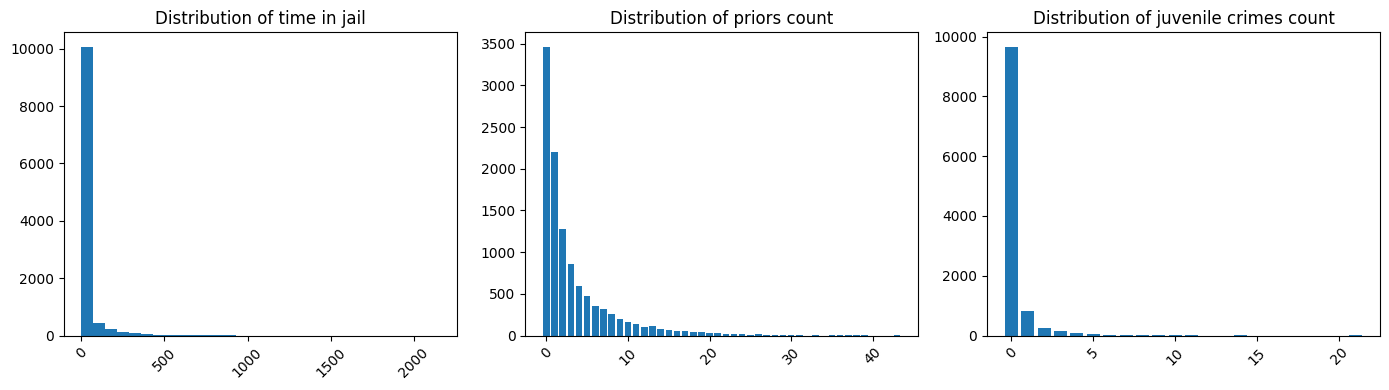

In [28]:
import matplotlib.pyplot as plt

times_in_jail_counts = df['time_in_jail'].value_counts().sort_index()
priors_counts = df['priors_count'].value_counts().sort_index()
juv_crime_counts = df['juv_crime_count'].value_counts().sort_index()

fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].hist(df['time_in_jail'], bins=30, align='mid')
axs[0].set_title('Distribution of time in jail')
axs[0].tick_params(axis='x', rotation=45)

axs[1].bar(priors_counts.index, priors_counts)
axs[1].set_title('Distribution of priors count')
axs[1].tick_params(axis='x', rotation=45)

axs[2].bar(juv_crime_counts.index, juv_crime_counts)
axs[2].set_title('Distribution of juvenile crimes count')
axs[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The distributions of all three features are *right-skewed*, meaning most of the data points fall on the left side of the histogram with a long tail to the right. This suggests that there are outliers or extreme values that are much higher than the rest.

You can try a lot of different scaler to see which one better fit with these data. In this notebook, we will try the <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html">MinMaxScaler from sklearn</a>, which scales and translates each feature individually such that it is in the given range.

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['time_in_jail', 'priors_count', 'juv_crime_count']] = scaler.fit_transform(df[['time_in_jail', 'priors_count', 'juv_crime_count']])

Let's check the dataset after the scaling!

In [30]:
df

,sex,age_cat,race,decile_score,priors_count,c_charge_degree,is_recid,time_in_jail,juv_crime_count,crime_category
0,Male,Greater than 45,Other,1,0.000000,F,0,0.000000,0.000000,Violent and Serious Crimes
2,Male,25 - 45,African-American,3,0.000000,F,1,0.004647,0.000000,Violent and Serious Crimes
3,Male,Less than 25,African-American,4,0.093023,F,1,0.000465,0.047619,Drug Offenses
4,Male,Less than 25,African-American,8,0.023256,F,0,0.011617,0.047619,Drug Offenses
5,Male,25 - 45,Other,1,0.046512,F,0,0.011617,0.000000,Miscellaneous Offenses
...,...,...,...,...,...,...,...,...,...,...
11752,Male,Greater than 45,Other,3,0.023256,F,0,0.000465,0.000000,Theft and Fraud
11753,Male,Less than 25,Caucasian,7,0.069767,M,1,0.000465,0.380952,Violent and Serious Crimes
11754,Male,25 - 45,Other,4,0.000000,M,0,0.011617,0.000000,Violent and Serious Crimes
11755,Male,25 - 45,Caucasian,3,0.046512,M,0,0.000465,0.000000,Miscellaneous Offenses


It is now time to translate all the categorical feature in a way understandable by AI algorithms.

We will use the `get_dummies` method by Pandas, which will create a new binary feature for each categorical value in the dataset.

In [31]:
# We select only the categorical features for this step
categorical_columns = ['sex', 'age_cat', 'race', 'c_charge_degree', 'crime_category']
df_encoded = pd.get_dummies(df, columns=categorical_columns)

df_encoded

,decile_score,priors_count,is_recid,time_in_jail,juv_crime_count,sex_Female,sex_Male,age_cat_25 - 45,age_cat_Greater than 45,age_cat_Less than 25,...,race_Native American,race_Other,c_charge_degree_F,c_charge_degree_M,c_charge_degree_O,crime_category_Driving and Vehicle-Related Offenses,crime_category_Drug Offenses,crime_category_Miscellaneous Offenses,crime_category_Theft and Fraud,crime_category_Violent and Serious Crimes
0,1,0.000000,0,0.000000,0.000000,False,True,False,True,False,...,False,True,True,False,False,False,False,False,False,True
2,3,0.000000,1,0.004647,0.000000,False,True,True,False,False,...,False,False,True,False,False,False,False,False,False,True
3,4,0.093023,1,0.000465,0.047619,False,True,False,False,True,...,False,False,True,False,False,False,True,False,False,False
4,8,0.023256,0,0.011617,0.047619,False,True,False,False,True,...,False,False,True,False,False,False,True,False,False,False
5,1,0.046512,0,0.011617,0.000000,False,True,True,False,False,...,False,True,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11752,3,0.023256,0,0.000465,0.000000,False,True,False,True,False,...,False,True,True,False,False,False,False,False,True,False
11753,7,0.069767,1,0.000465,0.380952,False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
11754,4,0.000000,0,0.011617,0.000000,False,True,True,False,False,...,False,True,False,True,False,False,False,False,False,True
11755,3,0.046512,0,0.000465,0.000000,False,True,True,False,False,...,False,False,False,True,False,False,False,True,False,False


#### Data Balancing

It is now time for the last step in our pipeline. We need to check whether the database is balanced or not, i.e. if the number of "*no*" classes is equal to the number of "*yes*" classes

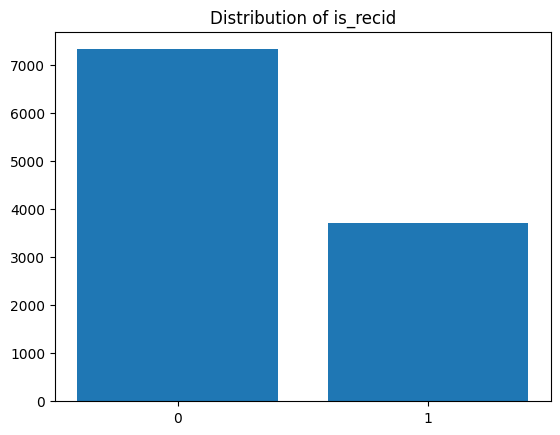

In [32]:
class_counts = df['is_recid'].value_counts()

plt.bar(class_counts.index, class_counts)
plt.title('Distribution of is_recid')
plt.xticks([0, 1])
plt.show()

We can see that our dataset is unbalanced, which might cause problems for the training phase.

We have to choose a technique to balance our data. We will use <a href="https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html">SMOTE</a>, which works by creating synthetic examples of the minority class, rather than simply duplicating existing ones. It does this by randomly picking a point from the minority class and then computing the k-nearest neighbors for this point.

In [33]:
# To use SMOTE, simply import it from imblearn
from imblearn.over_sampling import SMOTE

# N.B. We will not use decile_score for our prediction! So we're excluding both the target feature and decile_score
X = df_encoded.drop(columns=['is_recid','decile_score'])
y = df_encoded['is_recid']

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

We can now check the results of SMOTE.

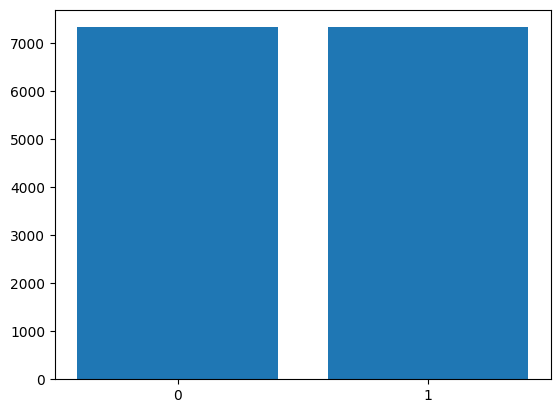

In [34]:
target_counts = y_smote.value_counts()

plt.bar(target_counts.index, target_counts)
plt.xticks(target_counts.index)
plt.show()

We're finally done with our pipeline! It's time to configure our AI algorithms to train and find the best predictor to our case.

#### Configuring the model

Now we configure our Decision Tree with the engineered dataset

In [35]:
from sklearn.model_selection import train_test_split

# Use the SMOTE X and y
X = X_smote
y = y_smote

# Define four sets and apply the function
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, # 0.2 indicates a test set size of 20%
                                                    random_state=42)

In [36]:
# Import the classifier and the metrics from sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

dt_clf = DecisionTreeClassifier(random_state=42)

# The fit function will do the trick
dt_clf.fit(X_train, y_train)

# After the training phase, the model will be tested by predicting the values on the test set
dt_predictions = dt_clf.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_recall = recall_score(y_test, dt_predictions)
dt_f1_score = f1_score(y_test, dt_predictions)
print(f"Decision Tree Accuracy: {dt_accuracy}")
print(f"Decision Tree Recall: {dt_recall}")
print(f"Decision Tree F1 Score: {dt_f1_score}")

Decision Tree Accuracy: 0.6885022176731491
Decision Tree Recall: 0.6443514644351465
Decision Tree F1 Score: 0.6693227091633466


#### Fairness Evaluation

In this section we will evaluate model's fairness level using the same metrics that we used with the non engineered pipeline.

In [37]:
from aif360.datasets import BinaryLabelDataset
from aif360.datasets import StandardDataset
from aif360.metrics import ClassificationMetric


sex_features = ['sex_Male','sex_Female'] # We want to check the fairness level regarding the protected attribute "sex"


dataset = X_test.copy(deep=True) # we create a copy of the test set
dataset['is_recid'] = y_test  # and join the target feature with the others

predictions = dataset.copy(deep=True) # we do the same task
predictions['is_recid'] = dt_predictions # but this time the target feature is made by the predictions of our model

# In this way, we have two datasets. One (dataset) is the original test set containing the original values of features,
# the other (predictions) contains the original values except for the target one, that is now made of model's predictions

# These will be used by AIF to compare the classifications of the model with the original values to
# understand if the model's answers create favouritism toward the privileged attribute


# This is the object made of the original dataset
aif_sex_dataset = BinaryLabelDataset( # Base class for all structured datasets with binary labels.
        df=dataset,
        favorable_label=1, # This means that a prediction is biased toward the privileged attribute if its value is 1 (True)
        unfavorable_label=0,
        label_names=['is_recid'],
        protected_attribute_names=sex_features,
        privileged_protected_attributes=['sex_Male'], # here we tell AIF that we want to check for predictions
                                                      # that somehow privilege the attribute "sex_Male"
    )

# We do the same thing but with the predictions dataset
aif_sex_pred = BinaryLabelDataset(
        df=predictions,
        favorable_label=1,
        unfavorable_label=0,
        label_names=['is_recid'],
        protected_attribute_names=sex_features,
        privileged_protected_attributes=['sex_Male'],
    )

sex_privileged_group = [{'sex_Male': 1, 'sex_Female': 0}] # The privileged group is made of males (sex_Male = True)
sex_unprivileged_group = [{'sex_Female': 1, 'sex_Male': 0}] # The unprivileged group is made of females (sex_Female = True)

# We provide the ClassificationMetric object with all the information needed:
# aif_sex_dataset - The original test set
# aif_sex_pred - A dataset containing the predictions of the model
# sex_privileged_group - The privileged group
# sex_unprivileged_group - The unprivileged group
fairness_metrics = ClassificationMetric(dataset=aif_sex_dataset,
                               classified_dataset=aif_sex_pred,
                               unprivileged_groups=sex_unprivileged_group,
                               privileged_groups=sex_privileged_group)

# Values less than 0 indicate that privileged group has higher
# proportion of predicted positive outcomes than unprivileged group.
# Value higher than 0 indicates that unprivileged group has higher proportion
# of predicted positive outcomes than privileged group.
SPD = round(fairness_metrics.statistical_parity_difference(),3)

# Measures the deviation from the equality of opportunity, which means that the same
# proportion of each population receives the favorable outcome. This measure must be equal to 0 to be fair.
EOD = round(fairness_metrics.equal_opportunity_difference(),3)

# Average of difference in False Positive Rate and True Positive Rate for unprivileged and privileged groups
# A value of 0 indicates equality of odds, which means that samples in both the privileged and unprivileged
# groups have the same probability of being classified positively.
AOD = round(fairness_metrics.average_odds_difference(),3)

print(f"Statistical Parity Difference (SPD): {SPD}")
print(f"Equal Opportunity Difference (EOD): {EOD}")
print(f"Average Odds Difference: {AOD}")



Statistical Parity Difference (SPD): -0.17
Equal Opportunity Difference (EOD): -0.06
Average Odds Difference: -0.102



#### 🗝 Key Observation 3

Remember? These were the metrics computed on a non-engineered pipeline:
- Statistical Parity Difference (SPD): -0.123
- Equal Opportunity Difference (EOD): -0.214
- Average Odds Differenc (AOD): -0.141

As we can see, some of them actually improved, as they became closer to 0 (when the values reach 0 the model is fair). This means that, although our model is still **unfair**, applying **Software Engineering** to **Artificial Intelligence** solutions improves their quality, both from a performance point of view and an ethical point of view.


# Bias Mitigation Algorithms

In the previous sections, we have computed different metrics to analyze the fairness level of our models. We have seen how engineering the ML pipeline can slightly mitigate the issue, but unfortunately, it is not enough.

The Software Engineering research community proposed several techniques that try to address fairness-related concerns in ML models from an algorithmic perspective. In this regard, different solutions have been proposed, and each operates in a different stage of the ML model development.

In this lab session, we will explore two **bias mitigation algorithms** from the AIF-360 toolkit:

- **Reweighing**: It is a *pre-processing* technique that Weights the examples in each (group, label) combination differently to ensure fairness before classification. Pre-processing techniques are applied *before* training the model, so they operate on the training set.

- **Exponentiated Gradient Reduction**: It is an *in-processing* technique that reduces fair classification to a sequence of cost-sensitive classification problems, returning a randomized classifier with the lowest empirical error subject to fair classification constraints. In-processing techniques act *during* the training phase of the model.


Another group of techniques is called *post-processing*. These solutions aim to address fairness-related issues after the model has been trained so they act on the predictions.

#### Reweighing (pre-process)

In [38]:
from aif360.algorithms.preprocessing import Reweighing


sex_features = ['sex_Male','sex_Female']

sex_privileged_group = [{'sex_Male': 1, 'sex_Female': 0}] # The privileged group is made of males (sex_Male = True)
sex_unprivileged_group = [{'sex_Female': 1, 'sex_Male': 0}] # The unprivileged group is made of females (sex_Female = True)

dataset = X_smote.copy(deep=True) # we recreate a copy of the whole dataset processed and balanced
dataset['is_recid'] = y_smote # and join the target feature with the others

# Create a BinaryLabelDataset using AIF360 library
aif_dataset = BinaryLabelDataset(
        df=dataset,
        favorable_label=1,
        unfavorable_label=0,
        label_names=['is_recid'],
        protected_attribute_names=sex_features,
    )

# Apply the Reweighing technique
RW = Reweighing(unprivileged_groups=sex_unprivileged_group, privileged_groups=sex_privileged_group)
dataset_transformed = RW.fit_transform(aif_dataset)

# Get sample weights from the transformed dataset
sample_weights = dataset_transformed.instance_weights

# Create a fair dataset using the reweighing technique
fair_dataset = dataset.copy(deep=True)
fair_dataset['weights'] = sample_weights

# Get features and target from the dataset
features = dataset.columns.tolist()
features.remove('is_recid')
target = ['is_recid']

# Set dataset features and target
X_fair = fair_dataset[features]
y_fair = fair_dataset[target]

X_fair_train, X_fair_test, y_fair_train, y_fair_test, sample_weights_train, sample_weights_test = train_test_split(X_fair, y_fair, sample_weights, test_size=0.2, random_state=42)


Now that we have everything setup, we can train our Decision Tree with the processed dataset.

In [39]:
# Import the classifier and the metrics from sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

fair_dt_clf = DecisionTreeClassifier(random_state=42)

# The fit function will do the trick
fair_dt_clf.fit(X_fair_train, y_fair_train, sample_weight=sample_weights_train)

# After the training phase, the model will be tested by predicting the values on the test set
fair_dt_predictions = fair_dt_clf.predict(X_fair_test)

fair_dt_accuracy = accuracy_score(y_fair_test, fair_dt_predictions)
fair_dt_recall = recall_score(y_fair_test, fair_dt_predictions)
fair_dt_f1_score = f1_score(y_fair_test, fair_dt_predictions)
print(f"Decision Tree Accuracy: {fair_dt_accuracy}")
print(f"Decision Tree Recall: {fair_dt_recall}")
print(f"Decision Tree F1 Score: {fair_dt_f1_score}")

Decision Tree Accuracy: 0.676560900716479
Decision Tree Recall: 0.6457461645746164
Decision Tree F1 Score: 0.6614285714285714


With this new model, let's evaluate the fairness metrics.

In [40]:
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric


sex_features = ['sex_Male','sex_Female'] # We want to check the fairness level regarding the protected attribute "sex"


dataset = X_fair_test.copy(deep=True) # we create a copy of the test set
dataset['is_recid'] = y_fair_test  # and join the target feature with the others

predictions = dataset.copy(deep=True) # we do the same task
predictions['is_recid'] = fair_dt_predictions # but this time the target feature is made by the predictions of our model

# In this way, we have two datasets. One (dataset) is the original test set containing the original values of features,
# the other (predictions) contains the original values except for the target one, that is now made of model's predictions

# These will be used by AIF to compare the classifications of the model with the original values to
# understand if the model's answers create favouritism toward the privileged attribute


# This is the object made of the original dataset
aif_sex_dataset = BinaryLabelDataset( # Base class for all structured datasets with binary labels.
        df=dataset,
        favorable_label=1, # This means that a prediction is biased toward the privileged attribute if its value is 1 (True)
        unfavorable_label=0,
        label_names=['is_recid'],
        protected_attribute_names=sex_features,
        privileged_protected_attributes=['sex_Male'], # here we tell AIF that we want to check for predictions
                                                      # that somehow privilege the attribute "sex_Male"
    )

# We do the same thing but with the predictions dataset
aif_sex_pred = BinaryLabelDataset(
        df=predictions,
        favorable_label=1,
        unfavorable_label=0,
        label_names=['is_recid'],
        protected_attribute_names=sex_features,
        privileged_protected_attributes=['sex_Male'],
    )

sex_privileged_group = [{'sex_Male': 1, 'sex_Female': 0}] # The privileged group is made of males (sex_Male = True)
sex_unprivileged_group = [{'sex_Female': 1, 'sex_Male': 0}] # The unprivileged group is made of females (sex_Female = True)

# We provide the ClassificationMetric object with all the information needed:
# aif_sex_dataset - The original test set
# aif_sex_pred - A dataset containing the predictions of the model
# sex_privileged_group - The privileged group
# sex_unprivileged_group - The unprivileged group
fairness_metrics = ClassificationMetric(dataset=aif_sex_dataset,
                               classified_dataset=aif_sex_pred,
                               unprivileged_groups=sex_unprivileged_group,
                               privileged_groups=sex_privileged_group)

# Values less than 0 indicate that privileged group has higher
# proportion of predicted positive outcomes than unprivileged group.
# Value higher than 0 indicates that unprivileged group has higher proportion
# of predicted positive outcomes than privileged group.
SPD = round(fairness_metrics.statistical_parity_difference(),3)

# Measures the deviation from the equality of opportunity, which means that the same
# proportion of each population receives the favorable outcome. This measure must be equal to 0 to be fair.
EOD = round(fairness_metrics.equal_opportunity_difference(),3)

# Average of difference in False Positive Rate and True Positive Rate for unprivileged and privileged groups
# A value of 0 indicates equality of odds, which means that samples in both the privileged and unprivileged
# groups have the same probability of being classified positively.
AOD = round(fairness_metrics.average_odds_difference(),3)

print(f"Statistical Parity Difference (SPD): {SPD}")
print(f"Equal Opportunity Difference (EOD): {EOD}")
print(f"Average Odds Difference: {AOD}")



Statistical Parity Difference (SPD): -0.103
Equal Opportunity Difference (EOD): -0.003
Average Odds Difference: -0.039


#### ExponentiatedGradientReduction (in-process)

To evaluate the trade-off between Social Sustainability and Environmental Sustainability, we will also compute energy consumption metrics using CodeCarbon

In [41]:
from aif360.sklearn.inprocessing import ExponentiatedGradientReduction

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker # We import the emission tracker
tracker = OfflineEmissionsTracker(country_iso_code="ITA") # the tracker object will compute the
                                                         # power consumption of our machine's components
                                                         # when executing a portion of the code.


sex_features = ['sex_Male','sex_Female']

tracker.start() # we tell CodeCarbon to start tracking

# First, we train our decision tree regularly
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

# We create an ExponentiatedGradientReduction object that acts on the trained model to change its internal behavior
processed_dt_clf = ExponentiatedGradientReduction(prot_attr=sex_features, estimator=dt_clf, constraints='DemographicParity', drop_prot_attr=False)

# Then we train again the same model updated with the reduction
fair_dt_clf = processed_dt_clf.fit(X_train, y_train)

# After the training phase, the model will be tested by predicting the values on the test set
fair_dt_predictions = fair_dt_clf.predict(X_test)

tracker.stop() # we tell CodeCarbon to stop tracking

fair_dt_accuracy = accuracy_score(y_test, fair_dt_predictions)
fair_dt_recall = recall_score(y_test, fair_dt_predictions)
fair_dt_f1_score = f1_score(y_test, fair_dt_predictions)
print(f"Decision Tree Accuracy: {fair_dt_accuracy}")
print(f"Decision Tree Recall: {fair_dt_recall}")
print(f"Decision Tree F1 Score: {fair_dt_f1_score}")

[codecarbon INFO @ 08:31:13] offline tracker init
[codecarbon INFO @ 08:31:13] [setup] RAM Tracking...
[codecarbon INFO @ 08:31:13] [setup] GPU Tracking...
[codecarbon INFO @ 08:31:13] No GPU found.
[codecarbon INFO @ 08:31:13] [setup] CPU Tracking...
[codecarbon WARNING @ 08:31:13] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon WARNING @ 08:31:14] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon INFO @ 08:31:14] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon INFO @ 08:31:14] >>> Tracker's metadata:
[codecarbon INFO @ 08:31:14]   Platform system: Linux-6.1.58+-x86_64-with-glibc2.35
[codecarbon INFO @ 08:31:14]   Python version: 3.10.12
[codecarbon INFO @ 08:31:14]   CodeCarbon version: 2.3.5
[codecarbon INFO @ 08:31:14]   Available RAM : 12.675 GB
[codecarbon INFO @ 08:31:14]   CPU count: 2
[codecarbon INFO @ 08:31:14]   CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz
[co

Decision Tree Accuracy: 0.676560900716479
Decision Tree Recall: 0.6457461645746164
Decision Tree F1 Score: 0.6614285714285714


Now we evaluate the effect of the algorithm

In [42]:
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric


sex_features = ['sex_Male','sex_Female'] # We want to check the fairness level regarding the protected attribute "sex"


dataset = X_test.copy(deep=True) # we create a copy of the test set
dataset['is_recid'] = y_test  # and join the target feature with the others

predictions = dataset.copy(deep=True) # we do the same task
predictions['is_recid'] = fair_dt_predictions # but this time the target feature is made by the predictions of our model

# In this way, we have two datasets. One (dataset) is the original test set containing the original values of features,
# the other (predictions) contains the original values except for the target one, that is now made of model's predictions

# These will be used by AIF to compare the classifications of the model with the original values to
# understand if the model's answers create favouritism toward the privileged attribute


# This is the object made of the original dataset
aif_sex_dataset = BinaryLabelDataset( # Base class for all structured datasets with binary labels.
        df=dataset,
        favorable_label=1, # This means that a prediction is biased toward the privileged attribute if its value is 1 (True)
        unfavorable_label=0,
        label_names=['is_recid'],
        protected_attribute_names=sex_features,
        privileged_protected_attributes=['sex_Male'], # here we tell AIF that we want to check for predictions
                                                      # that somehow privilege the attribute "sex_Male"
    )

# We do the same thing but with the predictions dataset
aif_sex_pred = BinaryLabelDataset(
        df=predictions,
        favorable_label=1,
        unfavorable_label=0,
        label_names=['is_recid'],
        protected_attribute_names=sex_features,
        privileged_protected_attributes=['sex_Male'],
    )

sex_privileged_group = [{'sex_Male': 1, 'sex_Female': 0}] # The privileged group is made of males (sex_Male = True)
sex_unprivileged_group = [{'sex_Female': 1, 'sex_Male': 0}] # The unprivileged group is made of females (sex_Female = True)

# We provide the ClassificationMetric object with all the information needed:
# aif_sex_dataset - The original test set
# aif_sex_pred - A dataset containing the predictions of the model
# sex_privileged_group - The privileged group
# sex_unprivileged_group - The unprivileged group
fairness_metrics = ClassificationMetric(dataset=aif_sex_dataset,
                               classified_dataset=aif_sex_pred,
                               unprivileged_groups=sex_unprivileged_group,
                               privileged_groups=sex_privileged_group)

# Values less than 0 indicate that privileged group has higher
# proportion of predicted positive outcomes than unprivileged group.
# Value higher than 0 indicates that unprivileged group has higher proportion
# of predicted positive outcomes than privileged group.
SPD = round(fairness_metrics.statistical_parity_difference(),3)

# Measures the deviation from the equality of opportunity, which means that the same
# proportion of each population receives the favorable outcome. This measure must be equal to 0 to be fair.
EOD = round(fairness_metrics.equal_opportunity_difference(),3)

# Average of difference in False Positive Rate and True Positive Rate for unprivileged and privileged groups
# A value of 0 indicates equality of odds, which means that samples in both the privileged and unprivileged
# groups have the same probability of being classified positively.
AOD = round(fairness_metrics.average_odds_difference(),3)

print(f"Statistical Parity Difference (SPD): {SPD}")
print(f"Equal Opportunity Difference (EOD): {EOD}")
print(f"Average Odds Difference: {AOD}")



Statistical Parity Difference (SPD): -0.016
Equal Opportunity Difference (EOD): 0.05
Average Odds Difference: 0.043


Lastly, we evaluate energy metrics.

In [43]:
emissions_csv = pd.read_csv("emissions.csv")
last_emissions = emissions_csv.tail(1) # we get the tail (the last computed values)

emissions = last_emissions["emissions"] * 1000
energy = last_emissions["energy_consumed"]
cpu = last_emissions["cpu_energy"]
gpu = last_emissions["gpu_energy"]
ram = last_emissions["ram_energy"]



print(f"{emissions} Grams of CO2-equivalents")
print(f"{energy} Sum of cpu_energy, gpu_energy and ram_energy (kWh)")
print(f"{cpu} Energy used per CPU (kWh)")
print(f"{gpu} Energy used per GPU (kWh)")
print(f"{ram} Energy used per RAM (kWh)")

1    0.034331
Name: emissions, dtype: float64 Grams of CO2-equivalents
1    0.000092
Name: energy_consumed, dtype: float64 Sum of cpu_energy, gpu_energy and ram_energy (kWh)
1    0.000083
Name: cpu_energy, dtype: float64 Energy used per CPU (kWh)
1    0
Name: gpu_energy, dtype: int64 Energy used per GPU (kWh)
1    0.000009
Name: ram_energy, dtype: float64 Energy used per RAM (kWh)


Metrics for the uncured pipeline:

- 0.001486 Grams of CO2-equivalents
- 0.000004 Sum of cpu_energy, gpu_energy and ram_energy (kWh)
- 0.000004 Energy used per CPU (kWh)
- 0 Energy used per GPU (kWh)
- 3.966632e-07 Energy used per RAM (kWh)

#### 🗝 Final Observation

Applying both a *pre-processing* and an *in-processing* technique made our model more **fair**, considering that all metrics are now closer to 0.

However, applying this algorithm produced **more CO2-equivalents** and **consumed more energy**.

But there is another consideration:

The model's performance in terms of accuracy, recall, and F1 score did not drop, if not for decimals. This means that the application of a bias mitigation technique has **not decreased** the model's performance but has **improved** its ethics.

**Why are we not using these techniques regularly?**

Of course, this is something that, in real-world scenarios, may be different, but we should carefully evaluate these trade-offs.